# Predictive Maintenance — Machine Failure Prediction

Dataset: AI4I 2020 Predictive Maintenance (synthetic, modeled after a real milling machine),
10,000 datapoints, 14 columns. Source: S. Matzka, "Explainable Artificial Intelligence for
Predictive Maintenance Applications," AI4I 2020.

**Goal**: predict `Machine failure` (binary) from process sensor readings, so failures can be
flagged before they happen.

The dataset also ships five failure-mode flags (`TWF`, `HDF`, `PWF`, `OSF`, `RNF`) that are
*components of the label itself* (`Machine failure = 1` iff at least one of them is 1). Those
are excluded from the feature set below — training on them would leak the answer.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              average_precision_score, f1_score, RocCurveDisplay,
                              PrecisionRecallDisplay)
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 1. Load & inspect data

In [2]:
df = pd.read_csv("data.csv")
print(df.shape)
df.head()

(10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
df.info()
print()
print("Missing values per column:")
print(df.isna().sum().sum(), "total missing values")

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

## 2. Class balance

Failures are rare (~3.4% of rows) — this is a classic imbalanced classification problem.
Accuracy alone will be misleading; we'll lean on **recall, precision, F1, ROC-AUC and PR-AUC**
for evaluation, and use class weighting during training.

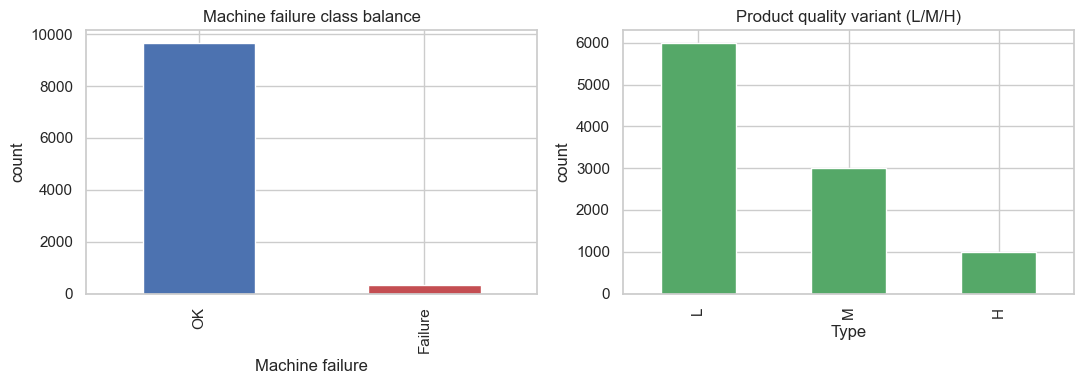

Overall failure rate: 3.39%


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df["Machine failure"].value_counts().rename({0: "OK", 1: "Failure"}).plot(
    kind="bar", ax=axes[0], color=["#4C72B0", "#C44E52"]
)
axes[0].set_title("Machine failure class balance")
axes[0].set_ylabel("count")

df["Type"].value_counts().plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Product quality variant (L/M/H)")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

fail_rate = df["Machine failure"].mean()
print(f"Overall failure rate: {fail_rate:.2%}")

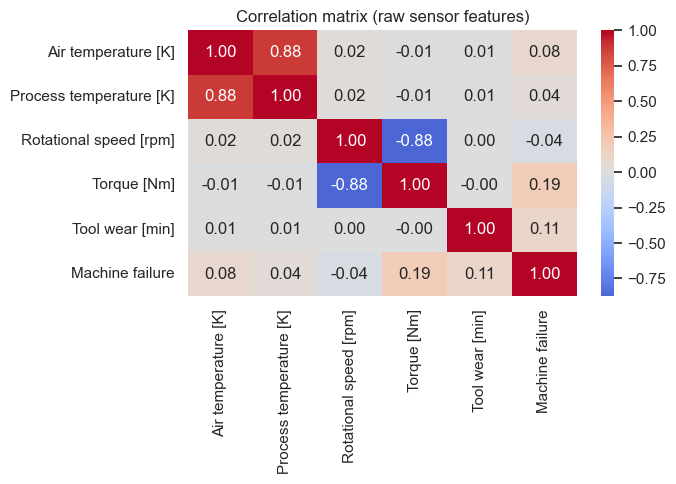

In [5]:
numeric_cols = ["Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]",
                "Torque [Nm]", "Tool wear [min]", "Machine failure"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix (raw sensor features)")
plt.tight_layout()
plt.show()

## 3. Feature engineering

Columns dropped:
- `UDI`, `Product ID` — identifiers, not predictive (and `Product ID` is high-cardinality).
- `TWF`, `HDF`, `PWF`, `OSF`, `RNF` — **label leakage**: these five flags are literally OR'd
  together to produce `Machine failure`, so a model given them would just learn the OR gate
  instead of anything about the underlying physics.

Three engineered features, derived only from the raw sensor columns (mirroring the physical
relationships the dataset's own failure modes are based on, but computed from measurements a
real deployment would actually have):
- `temp_diff_K` = process temp − air temp (relevant to heat-dissipation failure)
- `power_W` = torque × rotational speed × 2π/60 (relevant to power failure)
- `wear_torque` = tool wear × torque (relevant to overstrain failure)

In [6]:
LEAK_COLS = ["TWF", "HDF", "PWF", "OSF", "RNF"]
DROP_COLS = ["UDI", "Product ID"] + LEAK_COLS
TARGET = "Machine failure"

df["temp_diff_K"] = df["Process temperature [K]"] - df["Air temperature [K]"]
df["power_W"] = df["Torque [Nm]"] * df["Rotational speed [rpm]"] * (2 * np.pi / 60)
df["wear_torque"] = df["Tool wear [min]"] * df["Torque [Nm]"]

X = df.drop(columns=DROP_COLS + [TARGET])
y = df[TARGET]

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = ["Type"]
print("Numeric features:", num_cols)
print("Categorical features:", cat_cols)

Numeric features: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'temp_diff_K', 'power_W', 'wear_torque']
Categorical features: ['Type']


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train failure rate:", y_train.mean().round(4), " Test failure rate:", y_test.mean().round(4))

Train: (8000, 9)  Test: (2000, 9)
Train failure rate: 0.0339  Test failure rate: 0.034


## 4. Preprocessing + models

- `StandardScaler` on numeric features, `OneHotEncoder` on `Type`.
- Three candidates, each imbalance-aware:
  - **Logistic Regression** (`class_weight="balanced"`) — interpretable baseline.
  - **Random Forest** (`class_weight="balanced"`) — non-linear, robust to feature scale/outliers.
  - **XGBoost** (`scale_pos_weight` set to the train-set negative/positive ratio) — usually the
    strongest tabular performer.

In [8]:
pre = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first"), cat_cols),
])

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                             random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                              scale_pos_weight=pos_weight, random_state=RANDOM_STATE,
                              eval_metric="logloss"),
}

pipelines = {}
metrics_rows = []

for name, clf in models.items():
    pipe = Pipeline([("pre", pre), ("clf", clf)])
    pipe.fit(X_train, y_train)
    pipelines[name] = pipe

    proba = pipe.predict_proba(X_test)[:, 1]
    pred = pipe.predict(X_test)

    metrics_rows.append({
        "model": name,
        "roc_auc": roc_auc_score(y_test, proba),
        "pr_auc": average_precision_score(y_test, proba),
        "f1": f1_score(y_test, pred),
        "recall": (pred[y_test == 1] == 1).mean(),
        "precision": (y_test[pred == 1] == 1).mean() if (pred == 1).any() else np.nan,
    })

    print(f"\n{'='*10} {name} {'='*10}")
    print(classification_report(y_test, pred, digits=3))

metrics_df = pd.DataFrame(metrics_rows).set_index("model").sort_values("pr_auc", ascending=False)
metrics_df.round(3)


========== Logistic Regression ==========
              precision    recall  f1-score   support

           0      0.995     0.858     0.922      1932
           1      0.180     0.882     0.299        68

    accuracy                          0.859      2000
   macro avg      0.587     0.870     0.610      2000
weighted avg      0.967     0.859     0.900      2000




========== Random Forest ==========
              precision    recall  f1-score   support

           0      0.992     0.999     0.996      1932
           1      0.964     0.779     0.862        68

    accuracy                          0.992      2000
   macro avg      0.978     0.889     0.929      2000
weighted avg      0.991     0.992     0.991      2000




========== XGBoost ==========
              precision    recall  f1-score   support

           0      0.994     0.988     0.991      1932
           1      0.704     0.838     0.765        68

    accuracy                          0.983      2000
   macro avg      0.849     0.913     0.878      2000
weighted avg      0.984     0.983     0.983      2000



,roc_auc,pr_auc,f1,recall,precision
model,,,,,
XGBoost,0.983,0.886,0.765,0.838,0.704
Random Forest,0.980,0.879,0.862,0.779,0.964
Logistic Regression,0.938,0.430,0.299,0.882,0.180


## 5. Compare models

For a rare-failure problem, **PR-AUC** (average precision) is the most informative single
number — ROC-AUC is optimistic when negatives vastly outnumber positives.

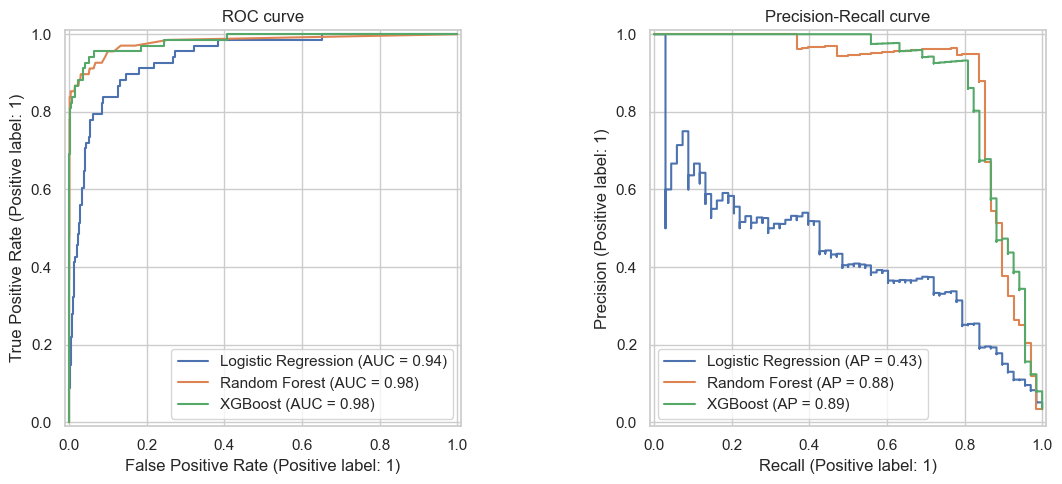

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for name, pipe in pipelines.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=axes[0], name=name)
    PrecisionRecallDisplay.from_estimator(pipe, X_test, y_test, ax=axes[1], name=name)

axes[0].set_title("ROC curve")
axes[1].set_title("Precision-Recall curve")
plt.tight_layout()
plt.show()

Best model by PR-AUC: XGBoost


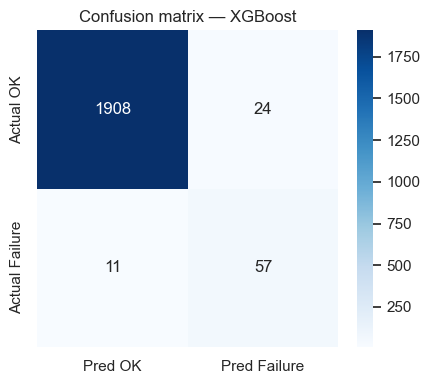

In [10]:
best_name = metrics_df["pr_auc"].idxmax()
best_pipe = pipelines[best_name]
print(f"Best model by PR-AUC: {best_name}")

pred = best_pipe.predict(X_test)
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred OK", "Pred Failure"], yticklabels=["Actual OK", "Actual Failure"])
plt.title(f"Confusion matrix — {best_name}")
plt.tight_layout()
plt.show()

## 6. Feature importance

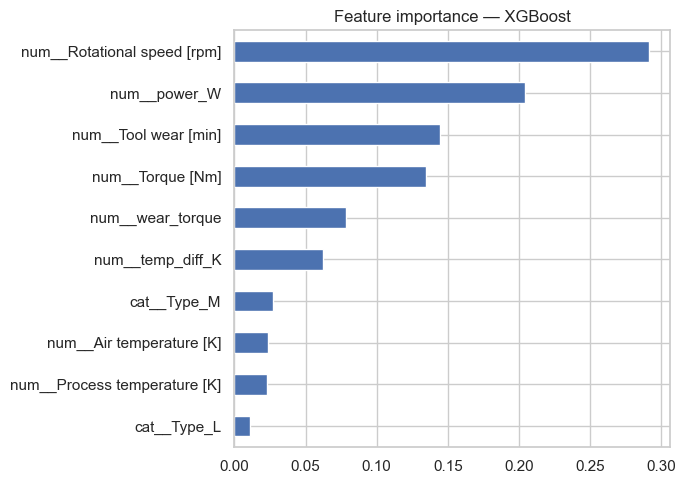

In [11]:
clf = best_pipe.named_steps["clf"]
feature_names = best_pipe.named_steps["pre"].get_feature_names_out()

if hasattr(clf, "feature_importances_"):
    importances = clf.feature_importances_
elif hasattr(clf, "coef_"):
    importances = np.abs(clf.coef_[0])
else:
    importances = None

if importances is not None:
    imp_df = pd.Series(importances, index=feature_names).sort_values(ascending=True)
    imp_df.plot(kind="barh", figsize=(7, 5), color="#4C72B0")
    plt.title(f"Feature importance — {best_name}")
    plt.tight_layout()
    plt.show()

## 7. 5-fold cross-validation (sanity check on PR-AUC)

Confirms the held-out result isn't a lucky split.

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(best_pipe, X, y, cv=cv, scoring="average_precision")
print(f"{best_name} 5-fold PR-AUC: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")
print(cv_scores.round(3))

XGBoost 5-fold PR-AUC: 0.866 +/- 0.021
[0.852 0.903 0.845 0.857 0.876]


## 8. Save the model

Persists the full pipeline (preprocessing + classifier) so new raw rows can be scored directly.

In [13]:
joblib.dump(best_pipe, "predictive_maintenance_model.joblib")
print(f"Saved {best_name} pipeline to predictive_maintenance_model.joblib")

Saved XGBoost pipeline to predictive_maintenance_model.joblib


## 9. Inference example

Score a few held-out rows through the saved pipeline exactly as a deployment would.

In [14]:
loaded = joblib.load("predictive_maintenance_model.joblib")

sample = X_test.sample(5, random_state=RANDOM_STATE)
sample_proba = loaded.predict_proba(sample)[:, 1]
sample_pred = loaded.predict(sample)

result = sample.copy()
result["failure_probability"] = sample_proba.round(3)
result["predicted_failure"] = sample_pred
result["actual_failure"] = y_test.loc[sample.index].values
result

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],temp_diff_K,power_W,wear_torque,failure_probability,predicted_failure,actual_failure
4701,H,303.5,311.7,1584,32.7,143,8.2,5424.148212,4676.1,0.002,0,0
8311,M,298.8,310.0,1295,52.7,74,11.2,7146.756768,3899.8,0.013,0,0
204,L,298.4,308.5,1741,32.8,112,10.1,5980.000672,3673.6,0.001,0,0
4985,M,303.8,313.0,1789,23.5,215,9.2,4402.575585,5052.5,0.089,0,0
6816,L,300.9,310.7,1477,43.2,143,9.8,6681.790583,6177.6,0.003,0,0


## Notes & next steps

- **Threshold tuning**: the default 0.5 decision threshold isn't necessarily optimal for a
  rare-event problem — pick a threshold on the PR curve above that matches the real cost of a
  missed failure vs. a false alarm.
- **Per-failure-mode models**: since `Machine failure` bundles five distinct causes (TWF, HDF,
  PWF, OSF, RNF), a production system would likely benefit from separate classifiers per mode
  (each with its own precision/recall tradeoff) rather than one blended label.
- **More data**: this is a synthetic 10k-row dataset; a real deployment should validate against
  live sensor logs and retrain periodically as tool wear / process drift changes.